<a href="https://colab.research.google.com/github/nehabansal26/AI-for-Biological-Sciences/blob/main/1D_diffusion_implicit_Runge_Kutta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Part 4: Deep dive into AI for biological sciences**

**Subtitle:** Pytorch implementation of PINNs with the Implicit Runge-Kutta method to reduce the requirement of collocation points

In previous post, we learned an approach to resolve the problem of requiring a lot of collocation points for training PINNs. The approach is the Runge-Kutta method, in which we discretise time and estimate the solution at current time point using the solution from the previous time point. We do so by taking multiple (can be 500) small steps between previous and current time points. Basically, we estimate the value of rate of change w.r.t time, called it slope values, at many time points between previous and current time points and take their weighted average. We also saw a nested non-linear form of equation that needs to solved to get the solution.

But, instead of solving the nested non-linear equations manually, by the way there are methods and libraries that can be used to solve them. But, here we take advantage of neural networks to predict the slope values at any number of time points that we want and use them to estimate the solution one time point at a time, sequentally.

In this post, we will learn how to integrate the Runge-Kutta method with PINNs and resolve the problem of sampling collocation points.

We take the same problem (from Post 2), in which a signalling protein (p) is diffusion through a cell chain of length L. The mathematical formulation for the problem is,
$$\frac{\partial p(x,t)}{\partial t} = D\frac{\partial^2 p(x,t)}{\partial x^2}, \quad x\in[0,L], \quad t\geq 0 \\ p(0,t) = 0,\quad t\geq 0 \\ p(L,t) = 0,\quad t\geq 0 \\p(x,0) = \sin(\pi x), \quad x\in[0,L]$$

Alright, let's begin. This time with inline code blocks, as implementation is much more involved then the previous version of PINNS (Post 3).


In [1]:
##:: import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.autograd.functional import jacobian


from numpy.polynomial.legendre import leggauss
from scipy.interpolate import lagrange
from scipy.integrate import quad
from scipy.io import loadmat


## Runge-Kutta method
Recall the core nested equation from previous post,
$$y_{n+1} = y_n + h\sum_{i=1}^{s} b_i f(y(t_n+c_i h),t_n + c_i h), \text{ (M1)}$$
$$y(t_n + c_i h) = y_n + h\sum_{j=1}^{s} a_{ij} f(y(t_n+c_j h), t_n + c_jh),\text{ (M2)}$$

Let's see what is function f and y is for our signalling protein problem.
$$y = p(x,t)$$
$$f(p,t) = D \frac{\partial^2p(x,t)}{\partial x^2}.$$

Now, we substitute our y and f into equation M1 and M2 and we get,
$$p_{n+1} = p_n + h\sum_{i=1}^{s} b_i D \frac{\partial^2p(x,t_n + c_i h)}{\partial x^2}$$
$$p(t_n + c_i h) = p_n + h\sum_{j=1}^{s} a_{ij} D \frac{\partial^2p(x,t_n + c_j h)}{\partial x^2}.$$

Alright, so we have many coefficients here for which we need values to move forward, which are
$$c_i, b_i, a_{ij}, \text{ where } i\in \{1,...,s\} \text{ and } j \in \{1,...,s\}.$$

In total we need
$$ s \text{ values for }   b \\ s \text{ values for }   c \\ s*s \text{ values for }   a$$


There are many methods to get the value of coefficients, here, we will use Gauss-Legendre method (Gauss is everywhere, if interested in do read the book BOOK NAME).


### Coefficeint estimation
There are various ways to estimate the coefficients. Here, we will learn the one mostly commonly used and one of its modification to speed up the computation.

#### Method: Gauss-Legendre method
For detailed explanation of the Gauss-Legendre method watch: https://www.youtube.com/watch?v=387Uczjp7do&t=15s.

In brief, Gauss-Legendre method is an approach to estimate integral of a polynomial. We first define the degree of the polynomial, which is same as number of stages of the Runge-Kutta method. Then we estimate the roots of the polynomial, which are the coefficients c for us. Then we estimate the weights at the roots, which are the coefficient b for us. The code is shown below. Note that, by default roots of the polynomial are in the interval -1 to 1. But time can't be negative, so shift the roots to 0 to 1 interval and adjust the corresponding weights.

In [85]:
s = 10  # number of stages for the Runge-Kutta method

# Legendre nodes and weights on [-1,1]
x, w = leggauss(s)

# Map nodes to [0,1]
c = (x + 1) / 2
b = w / 2

The coefficient c are used to create s different polynomials, let's call them P_j. Each of P_j's are then integrated upto c_i, i varying from 1 to s, to get a_ij.

In [86]:
A = np.zeros((s, s))

# Build Lagrange polynomials
for j in range(s):
    basis = np.zeros(s)
    basis[j] = 1
    poly = lagrange(c, basis)

    for i in range(s):
        A[i, j], _ = quad(poly, 0, c[i])

#### Computationally efficient Gauss-Legendre method

In [185]:

def gauss_rk_fast(s):

    # Gauss-Legendre nodes and weights on [-1,1]
    nodes, weights = leggauss(s)

    # map to [0,1]
    c = 0.5 * (nodes + 1)
    b = 0.5 * weights

    # Build Vandermonde matrix
    V = np.vander(c, N=s, increasing=True)

    # integrate monomials analytically
    Vinv = np.linalg.inv(V)

    A = np.zeros((s, s))

    for j in range(s):
        coeff = Vinv[:, j]

        for i in range(s):
            val = 0
            for k in range(s):
                val += coeff[k] * c[i]**(k+1)/(k+1)
            A[i, j] = val

    return A, b, c


s = 50
A, b, c = gauss_rk_fast(s)

print(A.shape, b.shape, c.shape)

(50, 50) (50,) (50,)


In [186]:
## Storing the coefficients
IRK_coeff_dict = {"c":torch.tensor(c,dtype=torch.float32), ## s (number of stages)
                  "b":torch.tensor(b,dtype=torch.float32), ## s
                  "a":torch.tensor(A,dtype=torch.float32) ## s x s
                  }

## Exact solution

Now, we need the exact solution for the protein signalling problem, which we know for this case, as it is a simple problem. We will use the exact solution to see how accurate is new PINNs solution. In case of complex problems, exact solution is unknownn, in that case nnumerical solvers such as OpenFoam are used to generate the training and validation data points.

The exact solution is given by,
$$p(x,t) = \exp(-\pi^2 t) \sin(\pi x/L).$$

We divide our cell chain of length 1m into 100 equally spaced points and time into 1000 equally space time points between 0 to 1s. Then we feed these x's and t's into the formula for exact solution.

Note that, this division of time is different from the stages in the Runge-Kutta Method. Here, we are in the realm of exact solution.

In [107]:
##:: training data: estimate the exact solution
L = 1 ## length of the cell chain
x_points = np.linspace(0,L,100) ## equally spaced points on the 1D cell chain
t_points = np.arange(0,1,0.001) ## equally spaced time points
exact_solution_list = [] ## list to store exact solution
for t in t_points:
    for x in x_points:
        exact_solution = np.exp(-np.pi**2*t)*np.sin(np.pi*x/L) ## formula for exact solution
        exact_solution_list.append([t,x,exact_solution])
exact_solution_df = pd.DataFrame(exact_solution_list, columns = ["Time","x","Exact Solution"]) ## exact solution list to dataframe conversion

Text(0.5, 1.0, 'Exact solution')

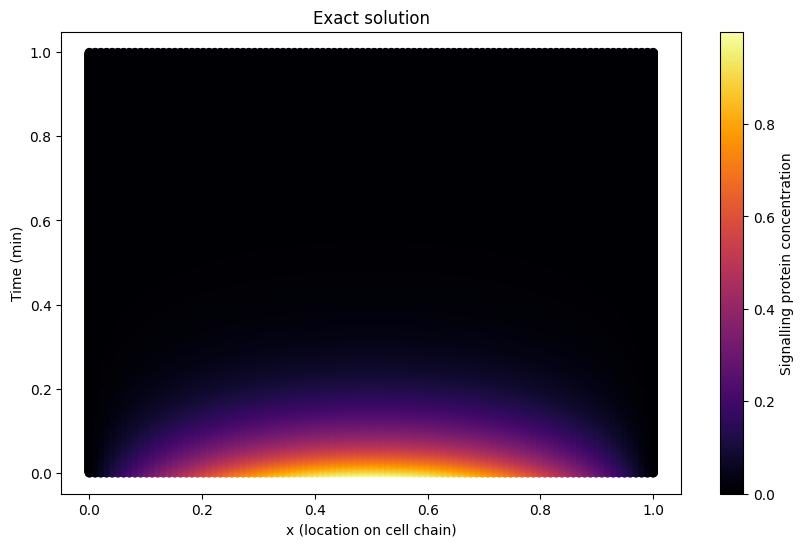

In [109]:
##:: plot of exact solution with respect to location (x) and time (t)
plt.figure(figsize=(10,6))
plt.scatter(x=exact_solution_df['x'], y=exact_solution_df['Time'], c = exact_solution_df['Exact Solution'], cmap="inferno")
plt.colorbar(label="Signalling protein concentration")
plt.xlabel("x (location on cell chain)")
plt.ylabel("Time (min)")
plt.title("Exact solution")

## Physical informed neural netwrok solution (PINNs)

Alright, we have gathered all the input for the PINNs, which are exact solution or training data and the coefficient for the Runge-Kutta method. It is time to integrate the Runge-Kutta into PINNs.

We have to integrate below two equations:
$$p(t_n + c_i h) = p_n + h\sum_{j=1}^{s} a_{ij} D \frac{\partial^2p(x,t_n + c_j h)}{\partial x^2},$$
$$ p_n =  p(t_n + c_i h) - h\sum_{j=1}^{s} a_{ij} D \frac{\partial^2p(x,t_n + c_j h)}{\partial x^2} \text{  (RK)}$$


We are going to implement RK into PINNs.

### PINNs network
In the class below, we define the structure of neural network. The components are,
- input size : We are providing only x as input, so input size is 1
- output size: We need estimates of s+1 values, so output size is s+1. s values inside the summation in equation (RK) and one value is for $p(t_n+c_i h)$, which is outside the summation.
- hidden layers: Number of layers we want in the neural network
- hidden neurons: Number of neurons in each hidden layer


In [8]:
##:: define the class for the neural network
class PINN1(nn.Module):
    def __init__(
        self,
        input_dim, ## dimension of input data, 2 as we have x and t
        output_dim, ## dimension of output, 1, as we predict p(x,t)
        hidden_layers=9, ## number of layers
        hidden_neurons=20, ## number of neurons in each layer
        activation=nn.Tanh ## activation function
    ):
        """
        Parameters
        ----------
        input_dim : int
            Number of input features
        output_dim : int
            Number of output neurons
        hidden_layers : int
            Number of hidden layers
        hidden_neurons : int
            Number of neurons per hidden layer
        activation : nn.Module
            Activation function class (e.g., nn.Tanh, nn.ReLU)
        """
        super().__init__()

        layers = [] ## list to store neural network layers

        # Input layer
        layers.append(nn.Linear(input_dim, hidden_neurons)) ## input layer takes x,t and project to higher dim
        layers.append(activation())

        # Hidden layers
        for _ in range(hidden_layers - 1):
            layers.append(nn.Linear(hidden_neurons, hidden_neurons))
            layers.append(activation())

        # Output layer
        layers.append(nn.Linear(hidden_neurons, output_dim)) ## projecting the higher dim to 1, our output dim

        self.model = nn.Sequential(*layers) ## assembling the layers

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            # smaller gain for PINNs
            nn.init.xavier_normal_(m.weight, gain=0.3)
            nn.init.zeros_(m.bias)

            # extra damping for output layer
            if m.out_features == 1:
                m.weight.data *= 0.1


    def forward(self, x):
        return self.model(x)

### Loss function
We are using good mean squared error between the exact solution and predicted solution from the PINNs as the loss, which is what gets optimised (minimized) in training of the neural network.

In [9]:
##:: function to calculate mean square loss
def pinn_loss(pred, true):
    loss_ = torch.mean((pred - true) ** 2)
    return loss_

### Biological information of boundary points

Recall the sink boundary points at $x=0$ and $x=L$, where signalling protein gets absorbed. To incorporate the sink boundary points as the biological information into PINNs, we minimize the loss at boundary points. We do so in a bit indirect way. We feed the two boundary points as inputs to the PINNs, get the prediction and prediction's first derivative. Since, both the input points are sinks, the difference between their predicted values should be $0$, that's what we implement later in training loop of the PINNs.

In [ ]:
def f_boundary(x, model):
    x = torch.tensor(x, dtype=torch.float32, requires_grad=True)

    p = model(x)  # (n, s+1)

    # ∂p/∂x # ∂²p/∂x²
    p_x = []
    for i in range(p.shape[1]):
        grad_i = torch.autograd.grad(
            p[:, i],
            x,
            grad_outputs=torch.ones_like(p[:, i]),
            create_graph=True
        )[0]

        p_x.append(grad_i)

    p_x = torch.stack(p_x, dim=1)

    return p,p_x

### RK integration
Yayy!!

Here we implement the Runge-Kutta method, that is, equation (RK)into the PINNS.

In [58]:
def f_0(x, dt, IRK_coeff, model):
    x = torch.tensor(x, dtype=torch.float32, requires_grad=True)

    p = model(x)  # (n, s+1)

    # ∂p/∂x # ∂²p/∂x²
    p_x = []
    p_xx = []
    for i in range(p.shape[1]):
        grad_i = torch.autograd.grad(
            p[:, i],
            x,
            grad_outputs=torch.ones_like(p[:, i]),
            create_graph=True
        )[0]

        grad_i1 = torch.autograd.grad(
            grad_i,
            x,
            grad_outputs=torch.ones_like(grad_i),
            create_graph=True
        )[0]

        p_x.append(grad_i)
        p_xx.append(grad_i1)

    p_x = torch.stack(p_x, dim=1) # (n,s+1,1)
    p_xx = torch.stack(p_xx, dim=1) # (n,s+1,1)
    p_xx = p_xx.squeeze(-1) # (n,s+1)

    RK_coeff_a_b_stack = torch.cat((IRK_coeff_dict['a'], IRK_coeff_dict['b'].unsqueeze(0)), dim=0) # (s+1,s)

    p_r = p -  dt*torch.matmul(p_xx[:,:-1], RK_coeff_a_b_stack.T) ## RK

    return p_r

### Training data preparation

It seems disconnected, kind of a standlone function. But, wait. We will use this function to calculate the loss for training the neural network in following steps.

Before that, let's define the training data for PINNs. We take snapshot of the exact solution at a time point and use them as our training data. We follow below steps:


1.  Select a time point $t_0$  
2.  Select a set of $N_0$ random  points on the domain, which are the $x$-coordinates between $0$ and $L$
3. The exact solution at $N_0$ x-points at time $t_0$ is our training data.







In [142]:
##:: training data: estimate the exact solution
L = 1 ## length of the cell chain
x_points = np.linspace(0,L,100) ## equally spaced points on the 1D cell chain
t_points = np.arange(0,1,0.1) ## equally spaced time points
exact_solution_list = [] ## list to store exact solution
for t in t_points:
    for x in x_points:
        exact_solution = np.exp(-np.pi**2*t)*np.sin(np.pi*x/L) ## formula for exact solution
        exact_solution_list.append([t,x,exact_solution])
exact_solution_df = pd.DataFrame(exact_solution_list, columns = ["Time","x","Exact Solution"]) ## exact solution list to dataframe conversion

## storing the data
actual_data_dict = {"x": x_points.reshape(1,len(x_points)),
                    "t": t_points.reshape(1,len(t_points)),
                    "p": np.array([i[2] for i in exact_solution_list]).reshape(len(t_points),len(x_points)).T
                    }

In [146]:
N0 = 50 ### number of points at time t_0
idx_t = 1 ### time point t_0 for training data
idx_t1 = 3 ### next step time point

t_points =  actual_data_dict["t"].flatten()[:,None]
x_points =  actual_data_dict["x"].flatten()[:,None]
p_exact =  actual_data_dict["p"]

dt = t_points[idx_t1] - t_points[idx_t]
print(f"time step size: {dt[0]}")

idx_x = np.random.choice(p_exact.shape[0],N0,replace=False)
x0 = x_points[idx_x,:]
p0_exact = torch.tensor(p_exact[idx_x, idx_t][:, None], dtype=torch.float32)

## boundary data two points x=0 and x=L
x1 = np.vstack((0,1))


time step size: 0.20000000000000004


### Training the PINNs
Time to train the PINNs, here we call the integration of the Runge-Kutta steps for estimating loss between exact and predicted value fo s stages.

In [187]:
epochs = 20 ## number of iterations for neural network training

##:: define the neural network model architecture with parameter
model = PINN1(
    input_dim=1, ## input is just x-coordinate
    output_dim=s+1, ## number of stages in Runge-Kutta method plus 1
    hidden_layers=4,
    hidden_neurons=50,
    activation=nn.Tanh ## activation function
)

##:: optimizer for model training
optimizer = torch.optim.LBFGS(model.parameters(),
                              lr=1e-2,
                                max_iter=20,
                                max_eval=20,
                                history_size=50,
                                line_search_fn="strong_wolfe")

# time step size calculation and converting to torch.Tensor
dt_value = t_points[idx_t1] - t_points[idx_t]
dt = torch.tensor(dt_value, dtype=torch.float32)

##:: closure for the optimizer
def closure():
    optimizer.zero_grad()

    # # nth time step loss
    pred0 = f_0(x0, dt, IRK_coeff_dict, model)
    loss_0 = pinn_loss(pred0, p0_exact)

    # loss for boundary points
    pred1, pred1_x = f_boundary(x1, model)
    loss_1 = pinn_loss(pred1[0,:], pred1[1,:])
    loss_2 = pinn_loss(pred1_x[0,:], pred1_x[1,:])

    # Total loss
    loss = loss_0 + loss_1 + loss_2

    loss.backward()
    return loss

loss_ls = []

# Adam
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
for _ in range(epochs):
    loss = closure()
    loss_ls.append(loss.item())
    optimizer.step()

# LBFGS
optimizer = torch.optim.LBFGS(model.parameters(), lr = 1, max_iter=50,max_eval=20,history_size=50,line_search_fn="strong_wolfe")
for _ in range(60):
    loss = optimizer.step(closure)
    loss_ls.append(loss.item())

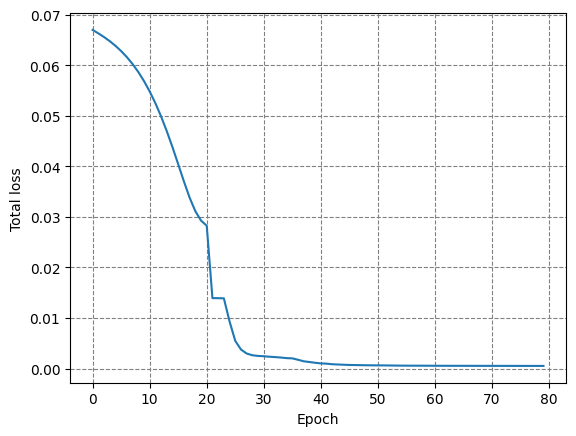

In [188]:
##:: plotting the loss vs network training iteration
plt.plot(loss_ls)
plt.xlabel("Epoch")
plt.ylabel("Total loss")
plt.grid(linestyle="--", color='grey')

## Comparison of exact solution and PINNs solution

In [189]:
##:: test data points
x_test_points = np.linspace(0,L,100).reshape(-1,1) ## equally spaced points on the 1D cell chain

##:: prediction on test data
model.eval()
with torch.no_grad():
    y_test_pred = model(torch.from_numpy(x_test_points).float())[:,-1]
y_test_pred_np = y_test_pred.detach().cpu().numpy().squeeze()

##:: exact solution on test data
y_test_actual =np.array([ np.exp(-np.pi**2*t_points[idx_t1])*np.sin(np.pi*x/L) for x in x_test_points])

##:: L2 error on test data
L2_error = np.mean(np.square(y_test_actual-y_test_pred_np))
print(f"L2 Error: {L2_error}")

L2 Error: 0.04271246084395318


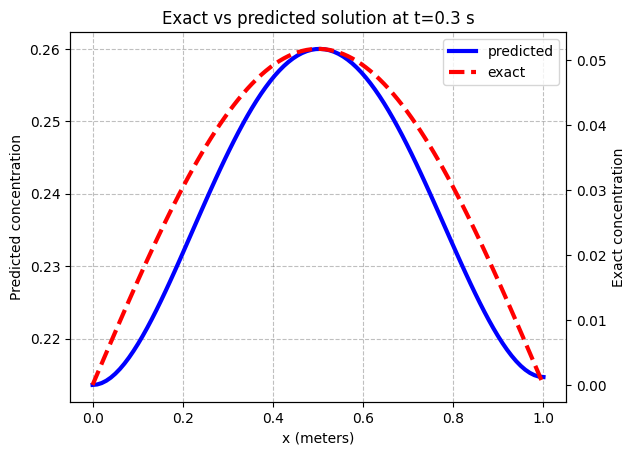

In [190]:
fig, ax1 = plt.subplots()

# first axis
ax1.plot(x_test_points, y_test_pred_np, label="predicted", color='blue', linewidth=3)
ax1.set_ylabel("Predicted concentration")
ax1.set_xlabel("x (meters)")

# second axis
ax2 = ax1.twinx()
ax2.plot(x_test_points, y_test_actual, label="exact", linestyle="--", color='red', linewidth=3)
ax2.set_ylabel("Exact concentration")

# grid and title
ax1.grid(linestyle='--', alpha=0.5, color='grey')
plt.title(f"Exact vs predicted solution at t={np.round(t_points[idx_t1][0],1)} s")

# combined legend
lines = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels)

plt.show()

We get an $L_2$ error $\sim 0.04$ at $t=0.3$s. We see that the overlap in actual solution versus predicted solution is not good, although the model is predicting the shape of the solution correctly. Another problem is the scale of values, PINNs is predicting values in the range of 0.22 to 0.25 whereas exact solution values are much lower in the range of 0 to 0.05. Note that, we are able to achieve this accuracy with $50$ training data points that too at single time point whereas in previous PINNs model, we used $1000$ data points at $100$ time points.

Now, the challenge remains in training a better model, which can be solved by exploring the model parameters, such as, number of stages of Runge-Kutta method, number of training iterations, number of layers, number of neurons in each layer, learning rate and optimiser parameters.

We saw an illustration on how to use PINNs with only 50 training data points at an initial time, that means we don't need to sample collocation points at each time point across the domain.

This concludes today's post. If you are interested in knowing how to improve the accuracy of the model by exploring model parameters and other technical aspects of neural network training, please comment below.

It is time to use these methods for a real problem you are working with or want to explore.

I will be doing so in coming posts.

In the next post, we will learn about a problem involving measuring the air flow velocity in indoor spaces, which can be used to model virus transmission. The following posts will have details of how to solve the problem with Pytorch code and extensive model training to achieve the target accuracy. Lots of exciting things to learn and experiment.